# 🎓 Smart Attendance Risk Predictor

## 📖 Project Overview

This project analyzes student attendance records using Python, Pandas, and NumPy.

### Project Features

- 📊 Calculate Overall Attendance Percentage
- 🧪 Analyze Practical Attendance
- ⚠️ Predict Attendance Risk Level
- ✅ Check Exam Eligibility
- 📚 Calculate Classes Needed to Reach 75%
- 🚫 Calculate Safe Bunks Remaining
- 📈 Generate Attendance Insights
- 📊 Visualize Data using Charts

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("student_data.csv")

data.head()

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave
0,101,Rahul Sharma,CSE,1,100,88,20,18,26,Yes,No
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No
3,104,Riya Gupta,AIML,1,100,81,20,17,24,Yes,No
4,105,Priya Yadav,IT,1,100,77,20,16,22,Yes,No


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Student_ID               25 non-null     int64 
 1   Student_Name             25 non-null     object
 2   Department               25 non-null     object
 3   Semester                 25 non-null     int64 
 4   Total_Classes            25 non-null     int64 
 5   Attended_Classes         25 non-null     int64 
 6   Practical_Total_Classes  25 non-null     int64 
 7   Practical_Attended       25 non-null     int64 
 8   Internal_Marks           25 non-null     int64 
 9   Assignments_Submitted    25 non-null     object
 10  Medical_Leave            25 non-null     object
dtypes: int64(7), object(4)
memory usage: 2.3+ KB


In [7]:
# Check missing values
data.isnull().sum()
# Check duplicate records
print("Duplicate Rows:", data.duplicated().sum())

# Remove duplicates
data = data.drop_duplicates()

print("Dataset Shape:", data.shape)

Duplicate Rows: 0
Dataset Shape: (25, 11)


In [8]:
data["Attendance_Percentage"] = (
    data["Attended_Classes"] /
    data["Total_Classes"]
) * 100

data.head()

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage
0,101,Rahul Sharma,CSE,1,100,88,20,18,26,Yes,No,88.0
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No,94.0
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No,69.0
3,104,Riya Gupta,AIML,1,100,81,20,17,24,Yes,No,81.0
4,105,Priya Yadav,IT,1,100,77,20,16,22,Yes,No,77.0


In [9]:
print("Average Attendance:",
      round(data["Attendance_Percentage"].mean(),2))

print("Highest Attendance:",
      data["Attendance_Percentage"].max())

print("Lowest Attendance:",
      data["Attendance_Percentage"].min())

Average Attendance: 79.6
Highest Attendance: 97.0
Lowest Attendance: 57.99999999999999


In [10]:
data["Practical_Percentage"] = (
    data["Practical_Attended"] /
    data["Practical_Total_Classes"]
) * 100

data.head()

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage,Practical_Percentage
0,101,Rahul Sharma,CSE,1,100,88,20,18,26,Yes,No,88.0,90.0
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No,94.0,100.0
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No,69.0,60.0
3,104,Riya Gupta,AIML,1,100,81,20,17,24,Yes,No,81.0,85.0
4,105,Priya Yadav,IT,1,100,77,20,16,22,Yes,No,77.0,80.0


In [11]:
print("Average Practical Attendance:",
      round(data["Practical_Percentage"].mean(),2))

print("Highest Practical Attendance:",
      data["Practical_Percentage"].max())

print("Lowest Practical Attendance:",
      data["Practical_Percentage"].min())

Average Practical Attendance: 79.2
Highest Practical Attendance: 100.0
Lowest Practical Attendance: 40.0


In [12]:
def risk(attendance):

    if attendance >= 90:
        return "Excellent"

    elif attendance >= 75:
        return "Safe"

    elif attendance >= 65:
        return "Warning"

    elif attendance >= 50:
        return "High Risk"

    else:
        return "Critical"

In [13]:
data["Risk_Level"] = data["Attendance_Percentage"].apply(risk)

data.head()

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage,Practical_Percentage,Risk_Level
0,101,Rahul Sharma,CSE,1,100,88,20,18,26,Yes,No,88.0,90.0,Safe
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No,94.0,100.0,Excellent
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No,69.0,60.0,Warning
3,104,Riya Gupta,AIML,1,100,81,20,17,24,Yes,No,81.0,85.0,Safe
4,105,Priya Yadav,IT,1,100,77,20,16,22,Yes,No,77.0,80.0,Safe


In [14]:
data["Exam_Eligibility"] = np.where(
    data["Attendance_Percentage"] >= 75,
    "Eligible",
    "Not Eligible"
)

data.head()

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage,Practical_Percentage,Risk_Level,Exam_Eligibility
0,101,Rahul Sharma,CSE,1,100,88,20,18,26,Yes,No,88.0,90.0,Safe,Eligible
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No,94.0,100.0,Excellent,Eligible
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No,69.0,60.0,Warning,Not Eligible
3,104,Riya Gupta,AIML,1,100,81,20,17,24,Yes,No,81.0,85.0,Safe,Eligible
4,105,Priya Yadav,IT,1,100,77,20,16,22,Yes,No,77.0,80.0,Safe,Eligible


In [15]:
top_students = data.sort_values(
    by="Attendance_Percentage",
    ascending=False
)

top_students.head(5)

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage,Practical_Percentage,Risk_Level,Exam_Eligibility
6,107,Neha Sharma,AIML,1,100,97,20,20,30,Yes,No,97.0,100.0,Excellent,Eligible
19,120,Nikita Sharma,AIML,1,100,95,20,20,30,Yes,No,95.0,100.0,Excellent,Eligible
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No,94.0,100.0,Excellent,Eligible
17,118,Simran Kaur,IT,1,100,92,20,20,29,Yes,No,92.0,100.0,Excellent,Eligible
10,111,Vivek Kumar,CSE,1,100,91,20,19,28,Yes,No,91.0,95.0,Excellent,Eligible


In [16]:
risk_students = data[
    data["Attendance_Percentage"] < 75
]

risk_students

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage,Practical_Percentage,Risk_Level,Exam_Eligibility
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No,69.0,60.0,Warning,Not Eligible
5,106,Arjun Kumar,CSE,1,100,63,20,10,17,No,No,63.0,50.0,High Risk,Not Eligible
7,108,Karan Singh,IT,1,100,72,20,14,20,No,No,72.0,70.0,Warning,Not Eligible
12,113,Harsh Sharma,AIML,1,100,67,20,11,19,No,No,67.0,55.0,Warning,Not Eligible
14,115,Rohit Singh,IT,1,100,58,20,8,16,No,No,58.0,40.0,High Risk,Not Eligible
18,119,Aditya Mishra,CSE,1,100,73,20,14,21,No,No,73.0,70.0,Warning,Not Eligible
20,121,Akash Verma,IT,1,100,66,20,12,18,No,No,66.0,60.0,Warning,Not Eligible
24,125,Mohit Sharma,CSE,1,100,61,20,9,17,No,No,61.0,45.0,High Risk,Not Eligible


In [17]:
#Department-wise Analysis

department = data.groupby("Department")[
    "Attendance_Percentage"
].mean()

department

Department
AIML    84.875000
CSE     78.100000
IT      75.714286
Name: Attendance_Percentage, dtype: float64

In [18]:
def classes_needed(attended, total):
    
    if (attended / total) * 100 >= 75:
        return 0
    
    classes = 0
    
    while ((attended + classes) / (total + classes)) * 100 < 75:
        classes += 1
    
    return classes

data["Classes_Needed"] = data.apply(
    lambda row: classes_needed(
        row["Attended_Classes"],
        row["Total_Classes"]
    ),
    axis=1
)

data[["Student_Name","Attendance_Percentage","Classes_Needed"]].head()    

,Student_Name,Attendance_Percentage,Classes_Needed
0,Rahul Sharma,88.0,0
1,Anjali Singh,94.0,0
2,Aman Verma,69.0,24
3,Riya Gupta,81.0,0
4,Priya Yadav,77.0,0


In [19]:
def safe_bunks(attended, total):
    
    bunks = 0
    
    while (attended / (total + bunks + 1)) * 100 >= 75:
        bunks += 1
    
    return bunks

data["Safe_Bunks"] = data.apply(
    lambda row: safe_bunks(
        row["Attended_Classes"],
        row["Total_Classes"]
    ),
    axis=1
)

data[["Student_Name","Attendance_Percentage","Safe_Bunks"]].head()

,Student_Name,Attendance_Percentage,Safe_Bunks
0,Rahul Sharma,88.0,17
1,Anjali Singh,94.0,25
2,Aman Verma,69.0,0
3,Riya Gupta,81.0,8
4,Priya Yadav,77.0,2


In [20]:
def suggestion(attendance):

    if attendance >= 90:
        return "Excellent! Keep it up."

    elif attendance >= 75:
        return "Maintain your attendance."

    else:
        return "Attend classes regularly."

In [21]:
data["Suggestion"] = data["Attendance_Percentage"].apply(suggestion)

data.head()

,Student_ID,Student_Name,Department,Semester,Total_Classes,Attended_Classes,Practical_Total_Classes,Practical_Attended,Internal_Marks,Assignments_Submitted,Medical_Leave,Attendance_Percentage,Practical_Percentage,Risk_Level,Exam_Eligibility,Classes_Needed,Safe_Bunks,Suggestion
0,101,Rahul Sharma,CSE,1,100,88,20,18,26,Yes,No,88.0,90.0,Safe,Eligible,0,17,Maintain your attendance.
1,102,Anjali Singh,AIML,1,100,94,20,20,29,Yes,No,94.0,100.0,Excellent,Eligible,0,25,Excellent! Keep it up.
2,103,Aman Verma,CSE,1,100,69,20,12,18,No,No,69.0,60.0,Warning,Not Eligible,24,0,Attend classes regularly.
3,104,Riya Gupta,AIML,1,100,81,20,17,24,Yes,No,81.0,85.0,Safe,Eligible,0,8,Maintain your attendance.
4,105,Priya Yadav,IT,1,100,77,20,16,22,Yes,No,77.0,80.0,Safe,Eligible,0,2,Maintain your attendance.


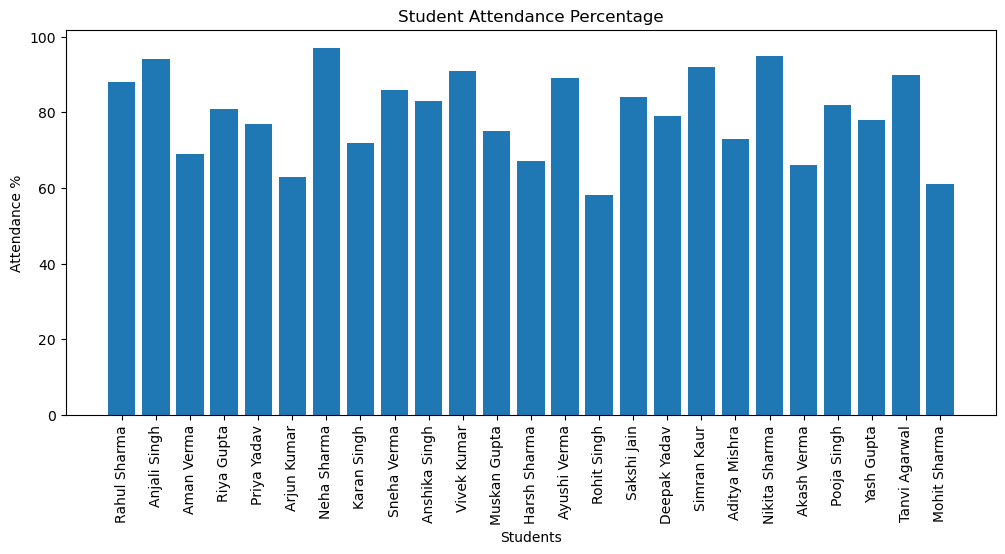

In [22]:
plt.figure(figsize=(12,5))

plt.bar(
    data["Student_Name"],
    data["Attendance_Percentage"]
)

plt.xticks(rotation=90)

plt.title("Student Attendance Percentage")

plt.xlabel("Students")
plt.ylabel("Attendance %")

plt.show()

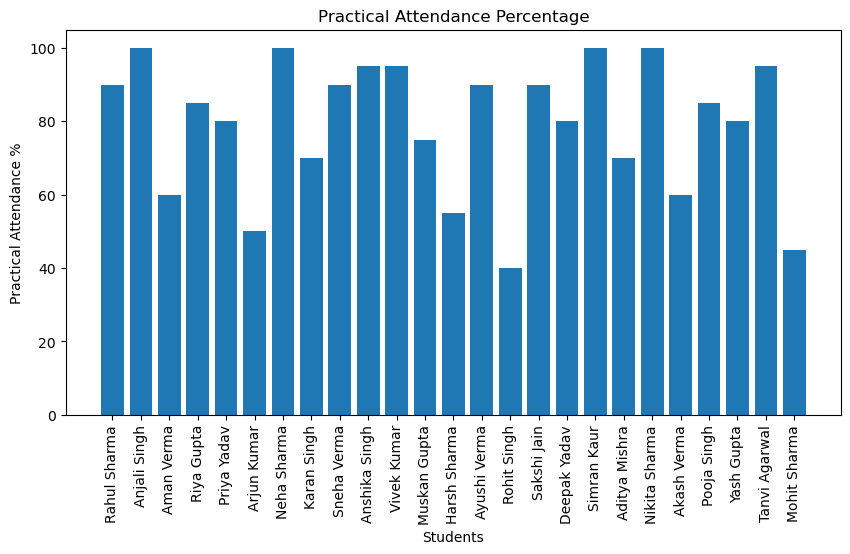

In [23]:
plt.figure(figsize=(10,5))

plt.bar(
    data["Student_Name"],
    data["Practical_Percentage"]
)

plt.xticks(rotation=90)

plt.title("Practical Attendance Percentage")

plt.xlabel("Students")

plt.ylabel("Practical Attendance %")

plt.show()

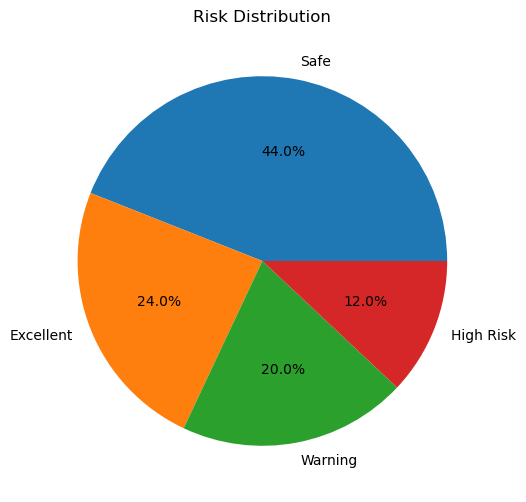

In [24]:
risk_count = data["Risk_Level"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    risk_count,
    labels=risk_count.index,
    autopct="%1.1f%%"
)

plt.title("Risk Distribution")

plt.show()

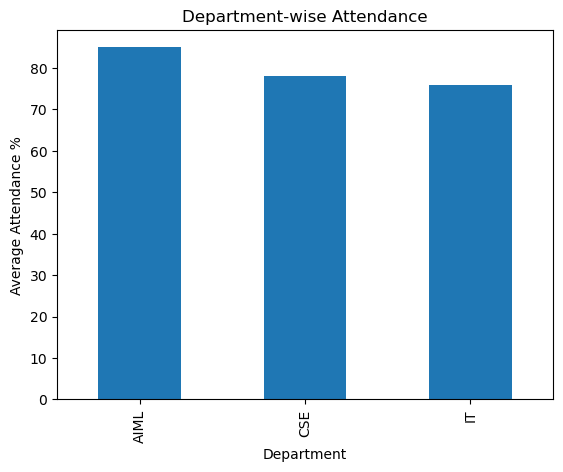

In [25]:
department.plot(kind="bar")

plt.title("Department-wise Attendance")

plt.ylabel("Average Attendance %")

plt.show()

In [26]:
student_report = data[[
"Student_Name",
"Attendance_Percentage",
"Practical_Percentage",
"Risk_Level",
"Exam_Eligibility",
"Classes_Needed",
"Safe_Bunks"
]]

student_report

,Student_Name,Attendance_Percentage,Practical_Percentage,Risk_Level,Exam_Eligibility,Classes_Needed,Safe_Bunks
0,Rahul Sharma,88.0,90.0,Safe,Eligible,0,17
1,Anjali Singh,94.0,100.0,Excellent,Eligible,0,25
2,Aman Verma,69.0,60.0,Warning,Not Eligible,24,0
3,Riya Gupta,81.0,85.0,Safe,Eligible,0,8
4,Priya Yadav,77.0,80.0,Safe,Eligible,0,2
5,Arjun Kumar,63.0,50.0,High Risk,Not Eligible,48,0
6,Neha Sharma,97.0,100.0,Excellent,Eligible,0,29
7,Karan Singh,72.0,70.0,Warning,Not Eligible,12,0
8,Sneha Verma,86.0,90.0,Safe,Eligible,0,14
9,Anshika Singh,83.0,95.0,Safe,Eligible,0,10


In [27]:
data.to_csv(
    "attendance_report.csv",
    index=False
)

# 🎯 Project Conclusion

This project successfully analyzed student attendance records and generated meaningful insights.

### Key Features

✅ Attendance Percentage Calculation

✅ Practical Attendance Analysis

✅ Attendance Risk Prediction

✅ Exam Eligibility Check

✅ Classes Required to Reach 75%

✅ Safe Bunks Remaining

✅ Department-wise Analysis

✅ Data Visualization

### Future Scope

- Email Alerts
- Interactive Dashboard using Streamlit
- AI-based Attendance Prediction
- Faculty Portal Integration